# CDS in-situ surface-marine — demo

End-to-end demo for the CDS [`insitu-observations-surface-marine`](https://cds.climate.copernicus.eu/datasets/insitu-observations-surface-marine) adapter: the `.env` → `CDSSource` → `CDSInsituArchive` pipeline, with a GeoParquet round-trip and a plot of observation locations.

Credentials live in the project-root `.env`:

```
CDSAPI_URL=https://cds.climate.copernicus.eu/api
CDSAPI_KEY=<uid>:<api-key>
```

Marine uses `data_format=csv`, accepts a server-side `area` filter, takes **one year per request** (the archive chunks by year; in this notebook we only pull one), and has **no** `time_aggregation` — it ships a single aggregation tier.

Scope: one year (2020), small eastern-Mediterranean bbox, default variables. Pulls ~50 MB / ~250 k rows.

## 1. Set up the adapter and archive

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from xrtoolz.data import CDSInsituArchive, CDSSource
from xrtoolz.types import BBox

In [2]:
import os
from pathlib import Path

def _default_scratch_root(subdir: str) -> Path:
    """Same resolver as scripts/_cds_insitu_common._default_scratch_root."""
    for var in ("CDS_INSITU_SCRATCH_ROOT", "XR_TOOLZ_CDS_ROOT"):
        override = os.environ.get(var)
        if override:
            return Path(override).expanduser() / subdir
    shared = Path("/home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch")
    if shared.is_dir():
        return shared / "cds_insitu" / subdir
    # Last-resort local fallback. Repo .gitignore excludes scratch/.
    return Path.cwd() / "scratch" / subdir

scratch = _default_scratch_root('marine_demo')
archive = CDSInsituArchive(
    root=scratch,
    preset='cds_insitu_marine',
    source=CDSSource(),  # reads CDSAPI_URL / CDSAPI_KEY from .env
)
archive.preset_root

PosixPath('/home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/cds_insitu/marine_demo/cds_insitu_marine')

## 2. Sync one year over a small bbox

East Mediterranean, 2020. Year-chunked; the archive records the completed chunk in `manifest.json` and re-running is a no-op.

In [3]:
bbox = BBox(lon_min=22.0, lon_max=36.5, lat_min=30.0, lat_max=41.0)
fresh = archive.sync("2020-01-01", "2020-12-31", bbox=bbox)
len(fresh)

2026-04-24 14:36:08,103 INFO Request ID is 18b3d66f-b79b-4634-ab1e-f45fad2686ef


2026-04-24 14:36:08,240 INFO status has been updated to accepted


2026-04-24 14:36:22,243 INFO status has been updated to running


2026-04-24 14:36:30,098 INFO status has been updated to successful


4a95143e2fdebfbc045d719328386b65.zip:   0%|          | 0.00/51.9M [00:00<?, ?B/s]

...

4a95143e2fdebfbc045d719328386b65.zip:  75%|███████▌  | 39.0M/51.9M [00:02<00:00, 27.5MB/s]

4a95143e2fdebfbc045d719328386b65.zip:  81%|████████  | 42.0M/51.9M [00:02<00:00, 28.2MB/s]

4a95143e2fdebfbc045d719328386b65.zip:  87%|████████▋ | 45.0M/51.9M [00:02<00:00, 28.6MB/s]

4a95143e2fdebfbc045d719328386b65.zip:  94%|█████████▍| 49.0M/51.9M [00:03<00:00, 31.6MB/s]

369429

## 3. Read back the GeoParquet archive

In [4]:
gdf = archive.load()
gdf.head()

,station_id,time,lon,lat,variable,value,units,quality_flag,report_type,source_id,geometry
0,EUCDE27,2020-01-01 00:00:00+00:00,32.4,31.2,air_temperature,287.05,K,0,0,2,POINT (32.4 31.2)
1,MASKSTID,2020-01-01 00:00:00+00:00,32.4,31.2,air_temperature,287.05,K,0,0,2,POINT (32.4 31.2)
2,EUCDE27,2020-01-01 00:00:00+00:00,32.4,31.2,dew_point_temperature,283.35,K,0,0,2,POINT (32.4 31.2)
3,MASKSTID,2020-01-01 00:00:00+00:00,32.4,31.2,dew_point_temperature,283.35,K,0,0,2,POINT (32.4 31.2)
4,EUCDE27,2020-01-01 00:00:00+00:00,32.4,31.2,air_pressure_at_sea_level,101930.00,Pa,0,0,2,POINT (32.4 31.2)


In [5]:
gdf.groupby("variable").size().sort_values(ascending=False)

variable
air_pressure_at_sea_level    84389
air_temperature              81582
dew_point_temperature        76431
wind_speed                   44196
wind_from_direction          43565
water_temperature            39266
dtype: int64

## 4. Observation locations

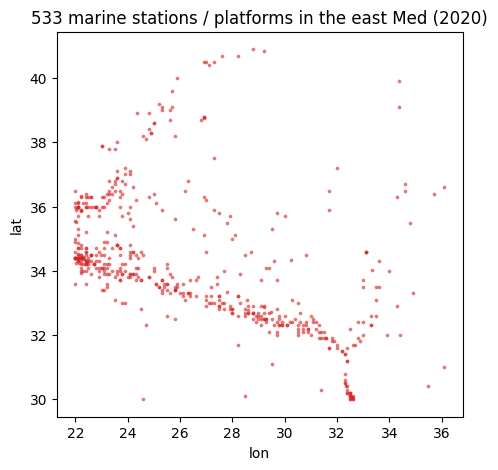

In [6]:
stations = archive.load_stations()
fig, ax = plt.subplots(figsize=(9, 5))
stations.plot(ax=ax, markersize=3, color="tab:red", alpha=0.5)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title(f"{len(stations)} marine stations / platforms in the east Med (2020)")
plt.show()

## 5. Per-variable time series

Daily mean over all platforms in the bbox.

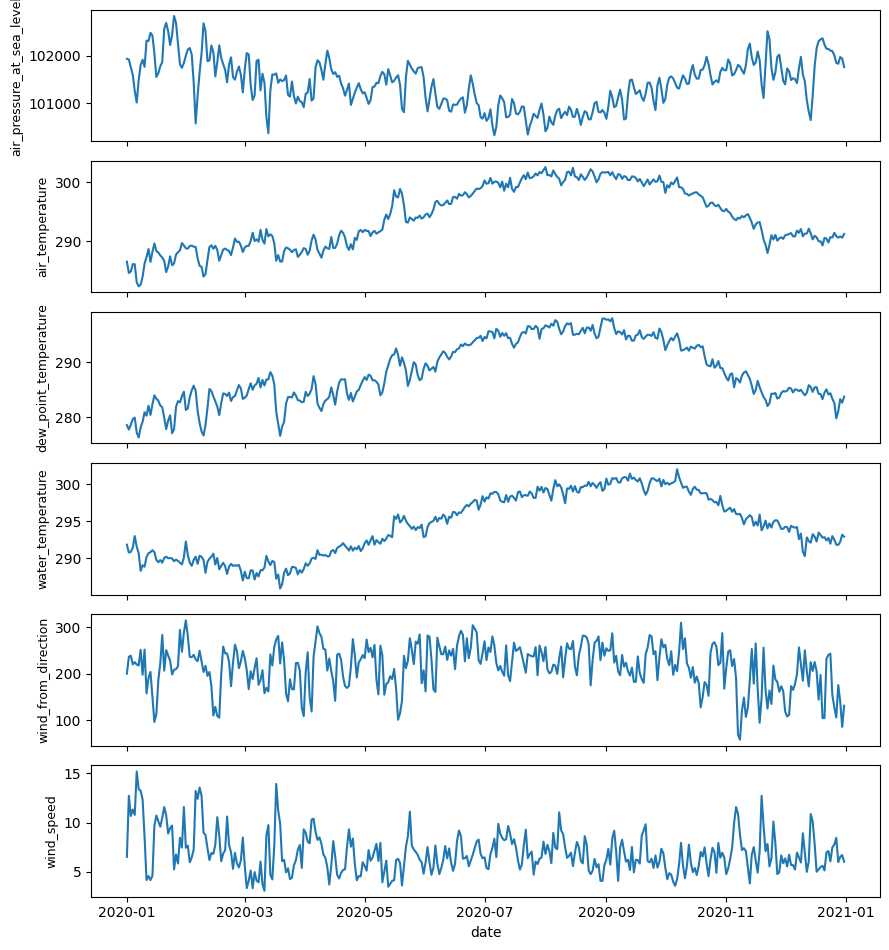

In [7]:
ts = (
    gdf.groupby(["variable", pd.Grouper(key="time", freq="1D")])["value"]
    .mean()
    .unstack("variable")
)
fig, axes = plt.subplots(len(ts.columns), 1, figsize=(9, 1.6 * len(ts.columns)), sharex=True)
for ax, var in zip(axes, ts.columns, strict=True):
    ax.plot(ts.index, ts[var])
    ax.set_ylabel(var, fontsize=9)
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()